# Phase 1 main experiment (part 1 of 2): drift localization

**Question.** When the frozen cold-start model meets a post-drift attack day,
can **dual-model SHAP divergence** identify *which* features drifted -- and does
it do so better than the cheaper baselines?

This notebook tests **localization only**. It is the gate: the adaptation /
efficiency experiment (notebook 08) is worth building only if localization
clears the pre-registered bar here.

**What it answers**

- **D012** (pre-registered): precision@K of localization vs a ground-truth
  drifted set, against the prediction-disagreement baseline.
- **Q007** (make-or-break): does dual-model divergence beat the auxiliary model's
  SHAP importance *alone*? On Wed-Fri the frozen model collapses to all-benign,
  so its SHAP may be near-zero -- if so, "divergence" could reduce to "aux
  importance" and the dual framing adds nothing.
- **Q008**: does input-distribution drift (KS) pick the same features as
  importance drift (SHAP)?

**Design in one paragraph.** Main model = frozen `cold_start`. For each day we
train an auxiliary RF on a window of that day's labelled traffic. Both models
produce a per-feature SHAP importance vector on a held-out sample. We score each
feature by several rules, take the top-K, and measure overlap with two
ground-truth sets. Tuesday is a **negative control** (the frozen model already
handles it, so the method should *not* fire strongly).

**Methods scored** (all per-feature, higher = more likely drifted):

| Name | Score | Role |
|---|---|---|
| `dual_gain` | relu(imp_aux - imp_main) | **the method (primary)** -- features that *gained* importance |
| `dual_abs` | \|imp_aux - imp_main\| | dual variant (symmetric) |
| `aux_only` | imp_aux | **Q007 baseline** -- auxiliary importance alone |
| `main_only` | imp_main | sanity (frozen model can't localize new attacks) |
| `perm_disagree` | permutation-disagreement | **D012 baseline** -- no SHAP |
| `random` | uniform | floor |

**Ground truths** (sets of size `GT_SIZE`):

- **GT1 (primary, unbiased):** top features by KS-D(Monday vs day). Pure
  input-distribution drift -- no model, no SHAP. The D012 verdict rests on GT1.
- **GT2 (diagnostic):** top features by *oracle* SHAP importance on the day.
  "What actually matters for detecting these attacks." Note GT2 structurally
  favours `aux_only` (aux approximates the oracle on the day it trained on), so
  it is supporting evidence, not the headline.


In [4]:
from pathlib import Path
d = Path('/content/drive/MyDrive/phd_thesis/src/divergence')
d.mkdir(parents=True, exist_ok=True)
(d / '__init__.py').touch()   # makes it an importable package, matching src/utils
print('created', d)

created /content/drive/MyDrive/phd_thesis/src/divergence


In [5]:
%%writefile /content/drive/MyDrive/phd_thesis/src/divergence/localization.py
"""
src/divergence/localization.py

Feature-level drift-localization helpers for Phase 1.

Given a frozen "main" model and a recently-trained "auxiliary" model, we score
each feature by how much the two models' SHAP importances disagree, and then
ask whether the top-scoring features match a ground-truth set of drifted
features. These are pure functions (no Drive paths, no globals) so they can be
unit-tested and reused by notebooks 07 (localization) and 08 (adaptation).

Scoring functions return a 1-D array of length n_features (higher = more
likely drifted). Evaluation functions compare a score vector against a
ground-truth index set.
"""
from __future__ import annotations
import numpy as np

try:
    import shap
except Exception:  # shap is optional at import time
    shap = None


# --------------------------------------------------------------------------- #
# SHAP importance
# --------------------------------------------------------------------------- #
def _to_class1(sv):
    """Normalise the several shapes shap.TreeExplainer returns for a binary
    classifier into a single (n_samples, n_features) array of class-1
    contributions."""
    if isinstance(sv, list):                       # [class0 (n,f), class1 (n,f)]
        return np.asarray(sv[1] if len(sv) > 1 else sv[0])
    arr = np.asarray(sv)
    if arr.ndim == 3:                              # (n, f, n_classes)
        return arr[:, :, 1] if arr.shape[2] > 1 else arr[:, :, 0]
    return arr                                     # already (n, f)


def shap_importance(model, X):
    """Mean absolute class-1 SHAP value per feature, normalised to sum to 1.

    Returns a 1-D np.ndarray of length n_features. Caller is responsible for
    subsampling X to a manageable size before calling (SHAP cost scales with
    n_samples).
    """
    if shap is None:
        raise ImportError('shap is not installed in this environment.')
    Xv = X.values if hasattr(X, 'values') else np.asarray(X)
    explainer = shap.TreeExplainer(model)
    sv = explainer.shap_values(Xv, check_additivity=False)
    arr = _to_class1(sv)
    imp = np.abs(arr).mean(axis=0)
    total = imp.sum()
    return imp / total if total > 0 else imp


# --------------------------------------------------------------------------- #
# Prediction-disagreement importance (the D012 "do you even need SHAP" baseline)
# --------------------------------------------------------------------------- #
def permutation_disagreement_importance(main_model, aux_model, X, seed=42):
    """Score each feature by how much permuting it changes the disagreement
    rate between the two models' predictions. Normalised to sum to 1.

    No SHAP involved -- this is the cheap baseline the dual-model SHAP method
    must beat to justify its cost.
    """
    rng = np.random.default_rng(seed)
    Xv = (X.values if hasattr(X, 'values') else np.asarray(X)).copy()
    base = float(np.mean(main_model.predict(Xv) != aux_model.predict(Xv)))
    n_features = Xv.shape[1]
    scores = np.zeros(n_features)
    for f in range(n_features):
        saved = Xv[:, f].copy()
        Xv[:, f] = rng.permutation(saved)
        d = float(np.mean(main_model.predict(Xv) != aux_model.predict(Xv)))
        scores[f] = abs(d - base)
        Xv[:, f] = saved
    total = scores.sum()
    return scores / total if total > 0 else scores


# --------------------------------------------------------------------------- #
# Ground-truth construction
# --------------------------------------------------------------------------- #
def ks_drift_scores(X_ref, X_cur):
    """Per-feature two-sample KS statistic between a reference sample and a
    current sample. Higher = more input-distribution drift on that feature."""
    from scipy.stats import ks_2samp
    Xr = X_ref.values if hasattr(X_ref, 'values') else np.asarray(X_ref)
    Xc = X_cur.values if hasattr(X_cur, 'values') else np.asarray(X_cur)
    n = Xr.shape[1]
    return np.array([ks_2samp(Xr[:, f], Xc[:, f]).statistic for f in range(n)])


# --------------------------------------------------------------------------- #
# Top-K and evaluation
# --------------------------------------------------------------------------- #
def topk_indices(scores, k):
    """Indices of the top-k scores, descending. Stable tie-break by index."""
    scores = np.asarray(scores, dtype=float)
    return list(np.argsort(-scores, kind='stable')[:k])


def precision_at_k(scores, ground_truth_idx, k):
    """Fraction of the top-k scored features that lie in the ground-truth set."""
    if k == 0:
        return float('nan')
    top = set(topk_indices(scores, k))
    gt = {int(i) for i in ground_truth_idx}
    return len(top & gt) / k


def recall_at_k(scores, ground_truth_idx, k):
    """Fraction of the ground-truth features captured in the top-k."""
    gt = {int(i) for i in ground_truth_idx}
    if not gt:
        return float('nan')
    top = set(topk_indices(scores, k))
    return len(top & gt) / len(gt)


def jaccard(idx_a, idx_b):
    """Jaccard overlap between two index sets."""
    a, b = {int(i) for i in idx_a}, {int(i) for i in idx_b}
    if not a and not b:
        return float('nan')
    return len(a & b) / len(a | b)


def random_precision_expectation(gt_size, n_features):
    """E[precision@k] for a uniformly random ranker = gt_size / n_features
    (independent of k under sampling without replacement)."""
    return gt_size / n_features

Overwriting /content/drive/MyDrive/phd_thesis/src/divergence/localization.py


## 1. Setup

In [6]:


import sys
sys.path.insert(0, '/content/drive/MyDrive/phd_thesis')
%pip install -q shap

import time, json, datetime
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score

from src.data.loaders import load_cicids2017
from src.utils.seeding import set_global_seed
from src.utils.documentation import log_finding, resolve_open_question, add_journal_entry
from src.divergence.localization import (
    shap_importance, permutation_disagreement_importance, ks_drift_scores,
    topk_indices, precision_at_k, recall_at_k, jaccard,
    random_precision_expectation,
)

ROOT = Path('/content/drive/MyDrive/phd_thesis')
FIGURES = ROOT / 'reports' / 'figures'
TABLES = ROOT / 'reports' / 'tables'
CHECKPOINTS = ROOT / 'experiments' / 'checkpoints'
DECISIONS_LOG = ROOT / 'reports' / 'advisor_notes' / 'decisions_log.md'
SUMMARY_JSON = ROOT / 'data' / 'processed' / 'phase1_07_localization.json'
for p in (FIGURES, TABLES, CHECKPOINTS):
    p.mkdir(parents=True, exist_ok=True)

# Load the frozen models and feature contract from notebook 06
with open(ROOT / 'data' / 'processed' / 'phase1_06_metadata.json') as f:
    meta06 = json.load(f)
FEATURE_COLS = meta06['feature_columns']
CONSTANT_FEATURES = meta06['constant_features_dropped']
RF_PARAMS = meta06['rf_hyperparameters']
N_FEATURES = len(FEATURE_COLS)

rf_cold = joblib.load(meta06['models']['cold_start'])     # frozen MAIN model
rf_oracle = joblib.load(meta06['models']['oracle'])       # privileged reference
print(f'Loaded cold_start (main) and oracle. {N_FEATURES} features.')

# ----- paper-quality plotting -----
PAPER_RCPARAMS = {
    'figure.dpi': 110, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05, 'savefig.facecolor': 'white',
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'font.family': 'serif', 'font.serif': ['DejaVu Serif', 'Times New Roman'],
    'font.size': 11, 'axes.titlesize': 12, 'axes.labelsize': 11,
    'xtick.labelsize': 10, 'ytick.labelsize': 10, 'legend.fontsize': 9,
    'axes.linewidth': 0.8, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linewidth': 0.5,
    'lines.linewidth': 1.8, 'lines.markersize': 6,
    'pdf.fonttype': 42, 'ps.fonttype': 42,
}
mpl.rcParams.update(PAPER_RCPARAMS)

METHOD_COLOR = {
    'dual_gain': '#009E73', 'dual_abs': '#56B4E9', 'aux_only': '#E69F00',
    'main_only': '#999999', 'perm_disagree': '#D55E00', 'random': '#000000',
}
METHOD_LABEL = {
    'dual_gain': 'Dual-gain (method)', 'dual_abs': 'Dual-abs',
    'aux_only': 'Aux-only', 'main_only': 'Main-only',
    'perm_disagree': 'Perm-disagree', 'random': 'Random',
}

def save_figure(fig, name):
    fig.savefig(FIGURES / f'{name}.png')
    fig.savefig(FIGURES / f'{name}.pdf')
    print(f'  saved: {name}.png / .pdf')

def log_decision(decision_id, decision, rationale, alternatives='',
                 context='07_localization_dual_shap'):
    today = datetime.date.today().isoformat()
    if DECISIONS_LOG.exists() and f'## {decision_id} \u2014' in DECISIONS_LOG.read_text():
        print(f'[DECISION SKIPPED] {decision_id} already logged.')
        return
    entry = (f'\n## {decision_id} \u2014 {today}\n**Context:** `{context}`\n\n'
             f'**Decision:** {decision}\n\n**Rationale:** {rationale}\n\n')
    if alternatives:
        entry += f'**Alternatives considered:** {alternatives}\n'
    with open(DECISIONS_LOG, 'a') as f:
        f.write(entry)
    print(f'[DECISION LOGGED] {decision_id}')

print('Setup complete.')


Loaded cold_start (main) and oracle. 82 features.
Setup complete.


## 2. D017 -- scope split (localization here, adaptation in notebook 08)

In [7]:
log_decision(
    decision_id='D017',
    decision=(
        'Split the Phase 1 main experiment across two notebooks. Notebook 07 '
        '(this one) tests LOCALIZATION only: precision@K of dual-model SHAP '
        'divergence vs ground-truth drifted features, against aux_only (Q007) '
        'and permutation-disagreement (D012) baselines. Notebook 08 will test '
        'ADAPTATION/EFFICIENCY: the streaming retrain loop with the D016 '
        'baselines (periodic_retrain, random_trigger) and recovery latency, '
        'built only if localization clears the D012 bar. Primary method is '
        'dual_gain = relu(imp_aux - imp_main), pre-registered on the principled '
        'grounds that drift localization should reward features that GAINED '
        'importance, not features that merely lost it.'
    ),
    rationale=(
        'Localization and adaptation are different questions with different '
        'cost profiles. Localization is cheap (no retrain loop) and is the gate '
        'that Q007/Q008/D012 hinge on. Building the expensive adaptation loop '
        'before localization passes risks wasted infrastructure. A toy '
        'relevance-swap check showed dual_abs can score WORSE than aux_only '
        '(symmetric difference rewards lost-importance features), motivating '
        'the directional dual_gain as the primary method. D016 anticipated '
        'this with its "notebook 07+" wording.'
    ),
    alternatives=(
        'One combined notebook (rejected: couples a cheap gate to an expensive '
        'loop, and mixes two questions). dual_abs as primary (rejected: '
        'directional gain is better motivated and survives the toy check).'
    ),
)


[DECISION LOGGED] D017


## 3. Configuration

Pre-registered before any result is computed. `dual_gain` is the primary
method; the D012 verdict uses post-drift mean precision@`K_PRIMARY` against
**GT1**, compared to the strongest baseline (max of `aux_only`, `perm_disagree`).


In [8]:
DAYS = ['tuesday', 'wednesday', 'thursday', 'friday']
CONTROL_DAY = 'tuesday'              # frozen model already handles this -> low signal expected
POST_DRIFT_DAYS = ['wednesday', 'thursday', 'friday']

K_PRIMARY = 10
K_SWEEP = [5, 10, 20]
GT_SIZE = 15                         # ground-truth set size (of 82 features)
SHAP_SAMPLE = 2000                   # stratified rows per SHAP/perm computation (D011)
KS_SAMPLE = 20000                    # rows per side for KS ground truth
AUX_TRAIN_CAP = 100000               # cap on auxiliary-model training rows (stratified)
AUX_TRAIN_FRAC = 0.6                 # day split: 60% train pool / 40% eval pool
SEEDS = [42, 1, 7]                   # method-side stochasticity (split, aux, sample)

PRIMARY_METHOD = 'dual_gain'
D012_BASELINES = ['aux_only', 'perm_disagree']   # method must beat the strongest of these
RANDOM_EXPECT = random_precision_expectation(GT_SIZE, N_FEATURES)

print(f'Days: {DAYS}  (control: {CONTROL_DAY})')
print(f'GT_SIZE={GT_SIZE} of {N_FEATURES} features  ->  random precision@K = {RANDOM_EXPECT:.3f}')
print(f'Primary method: {PRIMARY_METHOD}  |  seeds: {SEEDS}')


Days: ['tuesday', 'wednesday', 'thursday', 'friday']  (control: tuesday)
GT_SIZE=15 of 82 features  ->  random precision@K = 0.183
Primary method: dual_gain  |  seeds: [42, 1, 7]


## 4. Local helpers

The numeric core lives in `src/divergence/localization.py`. These three helpers
are orchestration-specific (sampling, auxiliary-model training, per-day day
loading), so they live here.


In [9]:
def stratified_sample(X, y, n, seed):
    """Stratified subsample of (X, y) to n rows. Falls back to random if
    a single class is present."""
    n = min(n, len(y))
    if y.nunique() < 2 or n >= len(y):
        idx = np.random.default_rng(seed).choice(len(y), size=n, replace=False)
        return X.iloc[idx].reset_index(drop=True), y.iloc[idx].reset_index(drop=True)
    idx, _ = train_test_split(np.arange(len(y)), train_size=n,
                              stratify=y, random_state=seed)
    return X.iloc[idx].reset_index(drop=True), y.iloc[idx].reset_index(drop=True)


def train_or_load_aux(day, seed, X_tr, y_tr):
    """Train (or load) the auxiliary RF for a given day and seed."""
    ckpt = CHECKPOINTS / f'rf_aux_{day}_s{seed}.joblib'
    if ckpt.exists():
        return joblib.load(ckpt)
    params = {**RF_PARAMS, 'random_state': seed}
    rf = RandomForestClassifier(**params).fit(X_tr, y_tr)
    joblib.dump(rf, ckpt)
    return rf


def load_day(day):
    """Load a CICIDS day, drop constants, enforce FEATURE_COLS order."""
    X, y, meta = load_cicids2017(day=day)
    X = X.drop(columns=CONSTANT_FEATURES, errors='ignore')[FEATURE_COLS]
    return X, y, meta

print('Helpers defined.')


Helpers defined.


## 5. Build ground truths (deterministic, once per day)

GT1 and GT2 are fixed per day (seed 42) so the method's per-seed variance is
measured against a stable target. We also record the GT1-vs-GT2 Jaccard overlap
-- the direct answer to Q008.


In [10]:
# Monday reference sample for KS (all-benign baseline the frozen model expects)
X_mon, y_mon, _ = load_day('monday')
mon_X, _ = stratified_sample(X_mon, y_mon, KS_SAMPLE, seed=42)

ground_truth = {}      # day -> {'GT1': idx, 'GT2': idx, 'ks': arr, 'oracle_imp': arr}
gt_overlap_rows = []

for day in DAYS:
    Xd, yd, _ = load_day(day)

    # GT1: KS input drift, Monday vs this day
    day_ks_X, _ = stratified_sample(Xd, yd, KS_SAMPLE, seed=42)
    ks = ks_drift_scores(mon_X, day_ks_X)
    gt1 = topk_indices(ks, GT_SIZE)

    # GT2: oracle SHAP importance on a fixed eval sample of this day
    _, ev_idx = train_test_split(np.arange(len(yd)), train_size=AUX_TRAIN_FRAC,
                                 stratify=yd if yd.nunique() > 1 else None,
                                 random_state=42)
    Xev42, yev42 = Xd.iloc[ev_idx].reset_index(drop=True), yd.iloc[ev_idx].reset_index(drop=True)
    Xs42, _ = stratified_sample(Xev42, yev42, SHAP_SAMPLE, seed=42)
    oracle_imp = shap_importance(rf_oracle, Xs42)
    gt2 = topk_indices(oracle_imp, GT_SIZE)

    ov = jaccard(gt1, gt2)
    ground_truth[day] = {'GT1': gt1, 'GT2': gt2, 'ks': ks, 'oracle_imp': oracle_imp}
    gt_overlap_rows.append({'day': day, 'gt1_gt2_jaccard': ov,
                            'max_ks': float(np.max(ks))})
    print(f'{day:<10} GT1/GT2 Jaccard={ov:.3f}   max KS-D={np.max(ks):.3f}')

gt_overlap_df = pd.DataFrame(gt_overlap_rows)


tuesday    GT1/GT2 Jaccard=0.429   max KS-D=0.076
wednesday  GT1/GT2 Jaccard=0.765   max KS-D=0.333
thursday   GT1/GT2 Jaccard=0.500   max KS-D=0.210
friday     GT1/GT2 Jaccard=0.765   max KS-D=0.456


## 6. Localization loop

For each day and seed: split the day, train the auxiliary model, compute the
main and auxiliary SHAP importance vectors on a held-out sample, derive every
method's score, and measure precision@K / recall@K against GT1 and GT2. We also
record the auxiliary model's recall (a precondition -- if the aux model can't
detect the day's attacks, its SHAP is meaningless) and the total divergence
magnitude (a detection-style signal that should be larger on post-drift days
than on the Tuesday control).


In [11]:
rows = []
precond = []
t_start = time.time()

for day in DAYS:
    Xd, yd, _ = load_day(day)
    gt1, gt2 = ground_truth[day]['GT1'], ground_truth[day]['GT2']

    for seed in SEEDS:
        # day split (seed-dependent)
        tr_idx, ev_idx = train_test_split(
            np.arange(len(yd)), train_size=AUX_TRAIN_FRAC,
            stratify=yd if yd.nunique() > 1 else None, random_state=seed)
        Xtr, ytr = Xd.iloc[tr_idx], yd.iloc[tr_idx]
        Xev, yev = Xd.iloc[ev_idx].reset_index(drop=True), yd.iloc[ev_idx].reset_index(drop=True)

        # auxiliary model on a capped, stratified training sample
        Xtr_s, ytr_s = stratified_sample(Xtr.reset_index(drop=True),
                                         ytr.reset_index(drop=True), AUX_TRAIN_CAP, seed)
        aux = train_or_load_aux(day, seed, Xtr_s, ytr_s)

        # held-out SHAP evaluation sample
        Xs, ys = stratified_sample(Xev, yev, SHAP_SAMPLE, seed)

        # precondition: does the aux model actually detect this day's attacks?
        aux_rec = (recall_score(ys, aux.predict(Xs), zero_division=0)
                   if ys.nunique() > 1 else float('nan'))
        precond.append({'day': day, 'seed': seed, 'aux_recall': aux_rec})

        # importance vectors
        imp_main = shap_importance(rf_cold, Xs)
        imp_aux = shap_importance(aux, Xs)
        perm = permutation_disagreement_importance(rf_cold, aux, Xs, seed=seed)

        diff = imp_aux - imp_main
        scores = {
            'dual_gain': np.clip(diff, 0, None),
            'dual_abs': np.abs(diff),
            'aux_only': imp_aux,
            'main_only': imp_main,
            'perm_disagree': perm,
            'random': np.random.default_rng(seed).random(N_FEATURES),
        }
        total_div = float(np.abs(diff).sum())

        for mname, sc in scores.items():
            for gtn, gtidx in (('GT1', gt1), ('GT2', gt2)):
                for k in K_SWEEP:
                    rows.append({
                        'day': day, 'seed': seed, 'method': mname, 'gt': gtn, 'k': k,
                        'precision': precision_at_k(sc, gtidx, k),
                        'recall': recall_at_k(sc, gtidx, k),
                        'total_divergence': total_div,
                        'aux_recall': aux_rec,
                    })
    print(f'{day:<10} done  ({time.time()-t_start:.0f}s elapsed)')

res = pd.DataFrame(rows)
precond_df = pd.DataFrame(precond)
res.to_csv(TABLES / '07_localization_raw.csv', index=False)
print(f'\n{len(res)} rows. Aux-model recall (precondition, should be high on every day):')
print(precond_df.groupby('day')['aux_recall'].mean().round(3).to_string())


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local

tuesday    done  (50s elapsed)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local

wednesday  done  (129s elapsed)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local

thursday   done  (208s elapsed)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local

friday     done  (269s elapsed)

432 rows. Aux-model recall (precondition, should be high on every day):
day
friday       0.999
thursday     0.997
tuesday      0.992
wednesday    1.000


## 7. Aggregate

In [12]:
def pivot_precision(gtn, k=K_PRIMARY):
    sub = res[(res['gt'] == gtn) & (res['k'] == k)]
    agg = sub.groupby(['day', 'method'])['precision'].agg(['mean', 'std']).reset_index()
    return agg.pivot(index='method', columns='day', values='mean').round(3)

method_order = ['dual_gain', 'dual_abs', 'aux_only', 'main_only', 'perm_disagree', 'random']
print(f'Precision@{K_PRIMARY} vs GT1 (KS input-drift) -- primary table:\n')
p_gt1 = pivot_precision('GT1').reindex(method_order)[DAYS]
print(p_gt1.to_string())
print(f'\nPrecision@{K_PRIMARY} vs GT2 (oracle importance) -- diagnostic:\n')
p_gt2 = pivot_precision('GT2').reindex(method_order)[DAYS]
print(p_gt2.to_string())

p_gt1.to_csv(TABLES / '07_precision_at_k_gt1.csv')
p_gt2.to_csv(TABLES / '07_precision_at_k_gt2.csv')

print(f'\nGT1/GT2 Jaccard overlap per day (Q008):')
print(gt_overlap_df.round(3).to_string(index=False))


Precision@10 vs GT1 (KS input-drift) -- primary table:

day            tuesday  wednesday  thursday  friday
method                                             
dual_gain        0.000      1.000     0.400   0.600
dual_abs         0.233      0.600     0.167   0.467
aux_only         0.200      1.000     0.500   0.633
main_only        0.200      0.300     0.300   0.200
perm_disagree    0.367      0.333     0.367   0.433
random           0.133      0.167     0.167   0.200

Precision@10 vs GT2 (oracle importance) -- diagnostic:

day            tuesday  wednesday  thursday  friday
method                                             
dual_gain        0.100      0.900     0.633   0.600
dual_abs         0.100      0.600     0.400   0.467
aux_only         0.200      0.933     0.733   0.633
main_only        0.100      0.200     0.100   0.300
perm_disagree    0.300      0.300     0.367   0.433
random           0.167      0.167     0.167   0.167

GT1/GT2 Jaccard overlap per day (Q008):
      day  gt1

## 8. Figures

  saved: 07_precision_gt1_by_method.png / .pdf


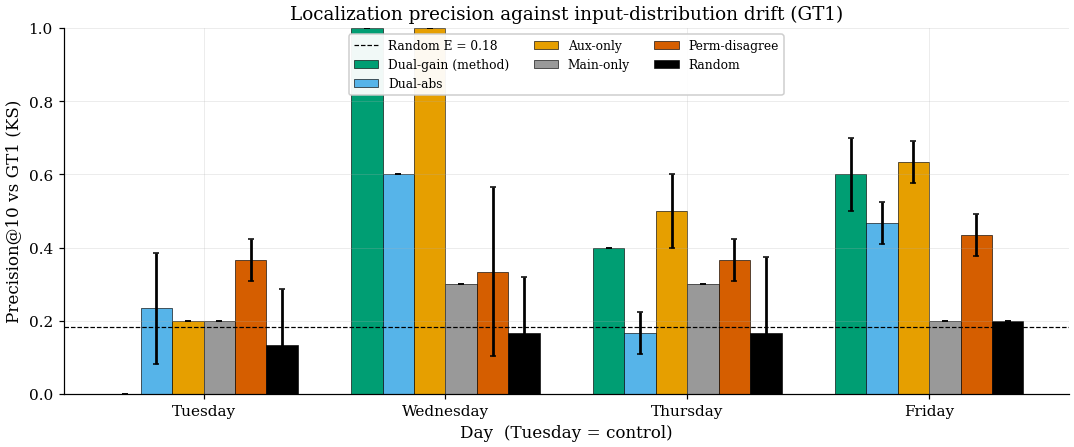

In [13]:
# ----- Figure 1: precision@K (GT1) by method across days -----
fig, ax = plt.subplots(figsize=(10, 4.3))
sub = res[(res['gt'] == 'GT1') & (res['k'] == K_PRIMARY)]
agg = sub.groupby(['day', 'method'])['precision'].agg(['mean', 'std']).reset_index()
x = np.arange(len(DAYS))
w = 0.13
for i, m in enumerate(method_order):
    means = [agg[(agg['day'] == d) & (agg['method'] == m)]['mean'].values[0] for d in DAYS]
    stds = [agg[(agg['day'] == d) & (agg['method'] == m)]['std'].values[0] for d in DAYS]
    ax.bar(x + (i - 2.5) * w, means, w, yerr=stds, capsize=2,
           color=METHOD_COLOR[m], label=METHOD_LABEL[m],
           edgecolor='black', linewidth=0.4)
ax.axhline(RANDOM_EXPECT, ls='--', color='black', lw=0.8,
           label=f'Random E = {RANDOM_EXPECT:.2f}')
ax.set_xticks(x); ax.set_xticklabels([d.capitalize() for d in DAYS])
ax.set_ylabel(f'Precision@{K_PRIMARY} vs GT1 (KS)')
ax.set_xlabel('Day  (Tuesday = control)')
ax.set_title('Localization precision against input-distribution drift (GT1)')
ax.set_ylim(0, 1.0)
ax.legend(ncol=3, fontsize=8, loc='upper center', framealpha=0.95)
fig.tight_layout(); save_figure(fig, '07_precision_gt1_by_method'); plt.show()


  saved: 07_q007_dual_vs_aux.png / .pdf


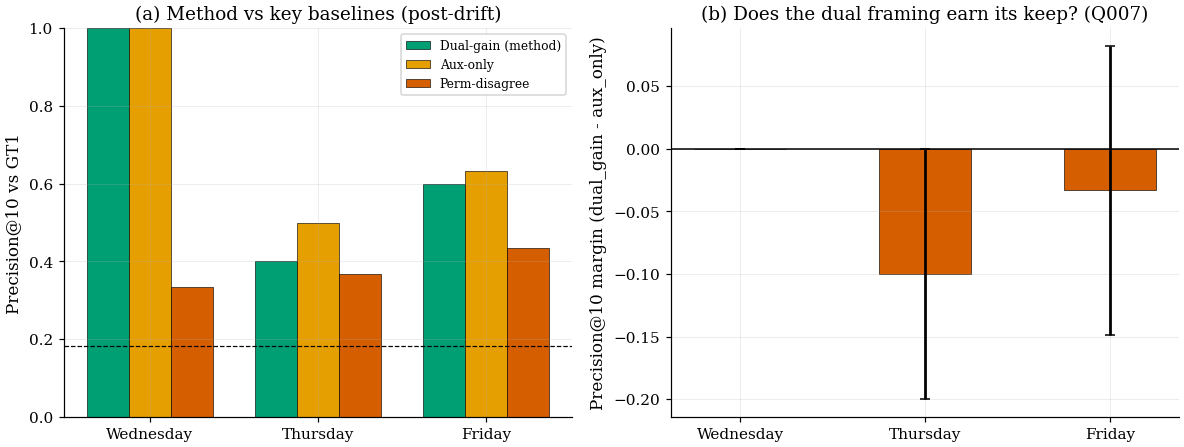

In [14]:
# ----- Figure 2: the Q007 question -- dual_gain minus aux_only, per day -----
sub = res[(res['gt'] == 'GT1') & (res['k'] == K_PRIMARY)]
agg = sub.groupby(['day', 'method'])['precision'].agg(['mean', 'std']).reset_index()
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))

# (a) dual_gain vs aux_only vs perm, post-drift, GT1
ax = axes[0]
comp = ['dual_gain', 'aux_only', 'perm_disagree']
x = np.arange(len(POST_DRIFT_DAYS)); w = 0.25
for i, m in enumerate(comp):
    means = [agg[(agg['day'] == d) & (agg['method'] == m)]['mean'].values[0] for d in POST_DRIFT_DAYS]
    ax.bar(x + (i - 1) * w, means, w, color=METHOD_COLOR[m],
           label=METHOD_LABEL[m], edgecolor='black', linewidth=0.4)
ax.axhline(RANDOM_EXPECT, ls='--', color='black', lw=0.8)
ax.set_xticks(x); ax.set_xticklabels([d.capitalize() for d in POST_DRIFT_DAYS])
ax.set_ylabel(f'Precision@{K_PRIMARY} vs GT1'); ax.set_ylim(0, 1.0)
ax.set_title('(a) Method vs key baselines (post-drift)')
ax.legend(fontsize=8)

# (b) margin dual_gain - aux_only (the Q007 delta), GT1
ax = axes[1]
deltas, errs = [], []
for d in POST_DRIFT_DAYS:
    dg = sub[(sub['day'] == d) & (sub['method'] == 'dual_gain')]['precision']
    ao = sub[(sub['day'] == d) & (sub['method'] == 'aux_only')]['precision']
    deltas.append(dg.mean() - ao.mean())
    errs.append(np.sqrt(dg.std()**2 + ao.std()**2))
colors = ['#009E73' if v > 0 else '#D55E00' for v in deltas]
ax.bar(range(len(POST_DRIFT_DAYS)), deltas, 0.5, yerr=errs, capsize=3,
       color=colors, edgecolor='black', linewidth=0.4)
ax.axhline(0, color='black', lw=1.0)
ax.set_xticks(range(len(POST_DRIFT_DAYS)))
ax.set_xticklabels([d.capitalize() for d in POST_DRIFT_DAYS])
ax.set_ylabel('Precision@10 margin (dual_gain - aux_only)')
ax.set_title('(b) Does the dual framing earn its keep? (Q007)')
fig.tight_layout(); save_figure(fig, '07_q007_dual_vs_aux'); plt.show()


  saved: 07_divergence_and_gt_overlap.png / .pdf


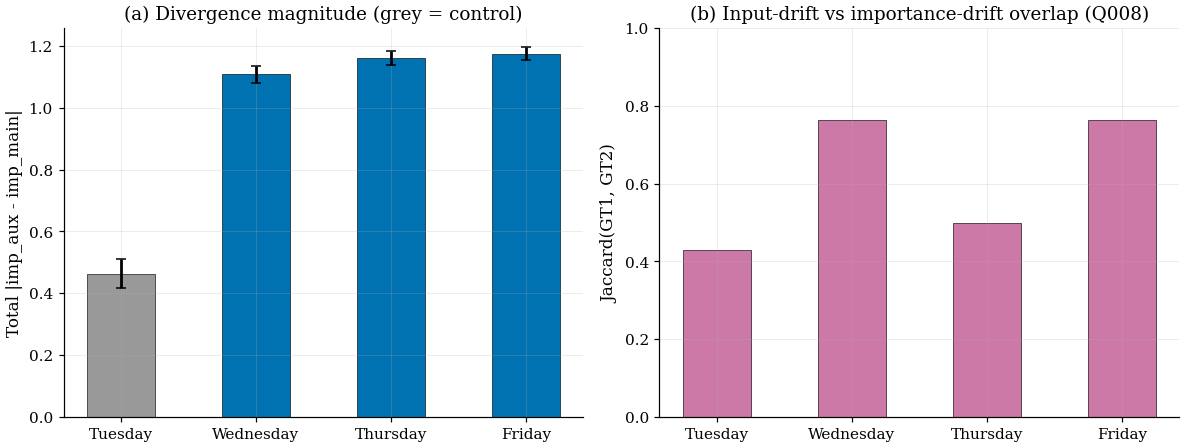

In [15]:
# ----- Figure 3: divergence magnitude + GT overlap -----
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))

ax = axes[0]
divg = res.groupby('day')['total_divergence'].agg(['mean', 'std']).reindex(DAYS)
bar_c = ['#999999' if d == CONTROL_DAY else '#0072B2' for d in DAYS]
ax.bar(range(len(DAYS)), divg['mean'], 0.5, yerr=divg['std'], capsize=3,
       color=bar_c, edgecolor='black', linewidth=0.4)
ax.set_xticks(range(len(DAYS))); ax.set_xticklabels([d.capitalize() for d in DAYS])
ax.set_ylabel('Total |imp_aux - imp_main|')
ax.set_title('(a) Divergence magnitude (grey = control)')

ax = axes[1]
ax.bar(range(len(DAYS)), gt_overlap_df.set_index('day').reindex(DAYS)['gt1_gt2_jaccard'],
       0.5, color='#CC79A7', edgecolor='black', linewidth=0.4)
ax.set_xticks(range(len(DAYS))); ax.set_xticklabels([d.capitalize() for d in DAYS])
ax.set_ylabel('Jaccard(GT1, GT2)'); ax.set_ylim(0, 1.0)
ax.set_title('(b) Input-drift vs importance-drift overlap (Q008)')
fig.tight_layout(); save_figure(fig, '07_divergence_and_gt_overlap'); plt.show()


## 9. Verdict (D012, Q007, Q008)

The verdict is computed from the numbers, not asserted. D012 uses post-drift
mean precision@`K_PRIMARY` against **GT1** for `dual_gain`, compared to the
strongest baseline (max of `aux_only`, `perm_disagree`).


In [16]:
def mean_p(method, days, gtn='GT1', k=K_PRIMARY):
    s = res[(res['method'] == method) & (res['day'].isin(days)) & (res['gt'] == gtn) & (res['k'] == k)]
    return float(s['precision'].mean())

dual = mean_p(PRIMARY_METHOD, POST_DRIFT_DAYS)
aux = mean_p('aux_only', POST_DRIFT_DAYS)
perm = mean_p('perm_disagree', POST_DRIFT_DAYS)
strongest = max(aux, perm)
margin = dual - strongest
q007_margin = dual - aux
control_dual = mean_p(PRIMARY_METHOD, [CONTROL_DAY])
gt_overlap_mean = float(gt_overlap_df[gt_overlap_df['day'].isin(POST_DRIFT_DAYS)]['gt1_gt2_jaccard'].mean())

# D012 tiering (honest handling of in-between cases)
if margin <= 0:
    verdict = 'WEAK'
elif dual > 0.70 and margin >= 0.20:
    verdict = 'STRONG'
elif dual >= 0.40 and margin >= 0.05:
    verdict = 'MODEST'
else:
    verdict = 'BELOW-MODEST'

print('=' * 64)
print('D012 VERDICT  (post-drift mean precision@%d vs GT1)' % K_PRIMARY)
print('=' * 64)
print(f'  dual_gain (method)      : {dual:.3f}')
print(f'  aux_only  (Q007 base)   : {aux:.3f}')
print(f'  perm_disagree (D012 base): {perm:.3f}')
print(f'  strongest baseline      : {strongest:.3f}')
print(f'  margin (method - best)  : {margin:+.3f}')
print(f'  random expectation      : {RANDOM_EXPECT:.3f}')
print(f'  --> D012 TIER: {verdict}')
print()
print('Q007  (does the dual framing beat aux-only?)')
print(f'  dual_gain - aux_only    : {q007_margin:+.3f}  '
      + ('-> dual earns its keep' if q007_margin > 0.02
         else '-> dual does NOT beat aux-only; reframe as aux-only localization'))
print()
print('Control check (Tuesday, should be modest/low):')
print(f'  dual_gain @ Tuesday     : {control_dual:.3f}')
print()
print('Q008  (input-drift vs importance-drift overlap, post-drift):')
print(f'  mean Jaccard(GT1,GT2)   : {gt_overlap_mean:.3f}  '
      + ('-> they largely agree' if gt_overlap_mean > 0.5
         else '-> they identify different features (a finding)'))


D012 VERDICT  (post-drift mean precision@10 vs GT1)
  dual_gain (method)      : 0.667
  aux_only  (Q007 base)   : 0.711
  perm_disagree (D012 base): 0.378
  strongest baseline      : 0.711
  margin (method - best)  : -0.044
  random expectation      : 0.183
  --> D012 TIER: WEAK

Q007  (does the dual framing beat aux-only?)
  dual_gain - aux_only    : -0.044  -> dual does NOT beat aux-only; reframe as aux-only localization

Control check (Tuesday, should be modest/low):
  dual_gain @ Tuesday     : 0.000

Q008  (input-drift vs importance-drift overlap, post-drift):
  mean Jaccard(GT1,GT2)   : 0.676  -> they largely agree


## 10. Record to the project log

Writes finding F005, resolves Q007 and Q008 with the measured numbers, saves
the summary JSON. Re-running is idempotent (findings/resolutions skip if already
present); to update after changing seeds, edit the entries by hand.


In [17]:
SUMMARY = {
    'generated': datetime.datetime.now().isoformat(timespec='seconds'),
    'seeds': SEEDS, 'gt_size': GT_SIZE, 'k_primary': K_PRIMARY,
    'random_expectation': RANDOM_EXPECT,
    'post_drift_precision_at_k_gt1': {
        m: mean_p(m, POST_DRIFT_DAYS) for m in method_order},
    'dual_gain': dual, 'aux_only': aux, 'perm_disagree': perm,
    'margin_vs_strongest_baseline': margin, 'q007_margin_dual_minus_aux': q007_margin,
    'control_day_dual_gain': control_dual, 'gt1_gt2_jaccard_postdrift': gt_overlap_mean,
    'd012_verdict': verdict,
}
with open(SUMMARY_JSON, 'w') as f:
    json.dump(SUMMARY, f, indent=2, default=str)
print(f'Saved {SUMMARY_JSON}')

log_finding(
    finding_id='F005',
    title='Dual-model SHAP localization on CICIDS2017 (notebook 07)',
    context='02_phase1_main/07_localization_dual_shap',
    what_we_did=(
        'Froze the cold-start model, trained a per-day auxiliary RF, and scored each '
        'feature by dual-model SHAP divergence (directional dual_gain), with aux_only, '
        'main_only, permutation-disagreement and random baselines. Measured precision@K '
        'against an input-drift ground truth (GT1, KS) and an oracle-importance ground '
        'truth (GT2), across a Tuesday control and three post-drift days, over 3 seeds.'
    ),
    what_we_found=(
        f'Post-drift mean precision@{K_PRIMARY} vs GT1: dual_gain={dual:.3f}, '
        f'aux_only={aux:.3f}, perm_disagree={perm:.3f} (random {RANDOM_EXPECT:.3f}). '
        f'Margin over strongest baseline = {margin:+.3f}; dual_gain - aux_only = '
        f'{q007_margin:+.3f}. Tuesday control dual_gain={control_dual:.3f}. '
        f'GT1/GT2 Jaccard (post-drift) = {gt_overlap_mean:.3f}. D012 tier: {verdict}.'
    ),
    why_it_matters=(
        'This is the gate for the whole approach. The D012 tier determines whether '
        'notebook 08 (adaptation/efficiency) proceeds as planned, narrows, or pivots; '
        'the Q007 margin determines whether the dual-model framing survives or is '
        'reframed as auxiliary-model explanation localization.'
    ),
)

resolve_open_question(
    'Q007',
    (f'Measured (post-drift, GT1, p@{K_PRIMARY}): dual_gain={dual:.3f} vs '
     f'aux_only={aux:.3f}, margin={q007_margin:+.3f}. '
     + ('Dual framing holds.' if q007_margin > 0.02
        else 'Dual does NOT beat aux-only; reframe as auxiliary-model explanation '
             'localization (see F005).')),
)
resolve_open_question(
    'Q008',
    (f'GT1 (KS input-drift) vs GT2 (oracle importance) Jaccard = {gt_overlap_mean:.3f} '
     f'(post-drift mean). '
     + ('Input-drift and importance-drift largely agree.' if gt_overlap_mean > 0.5
        else 'They identify substantially different features -- reported as a finding.')),
)
print('Documentation updated.')


Saved /content/drive/MyDrive/phd_thesis/data/processed/phase1_07_localization.json
[FINDING LOGGED] F005: Dual-model SHAP localization on CICIDS2017 (notebook 07)
[QUESTION RESOLVED] Q007
  -> Measured (post-drift, GT1, p@10): dual_gain=0.667 vs aux_only=0.711, margin=-0.044. Dual does NOT beat aux-only; reframe as auxiliary-model explanation localization (see F005).
[QUESTION RESOLVED] Q008
  -> GT1 (KS input-drift) vs GT2 (oracle importance) Jaccard = 0.676 (post-drift mean). Input-drift and importance-drift largely agree.
Documentation updated.


## 11. What this notebook establishes, and what comes next

The numbers above resolve the gate. Read the verdict honestly against the
pre-registered D012 tiers before deciding the next step:

- **STRONG or MODEST, and dual_gain beats aux-only** -> build notebook 08:
  the streaming adaptation loop with `periodic_retrain` and `random_trigger`
  (D016), measuring whether SHAP-triggered retraining recovers recall
  efficiently.
- **dual_gain does *not* beat aux-only (Q007)** -> the contribution reframes to
  *auxiliary-model explanation localization*. Still publishable, but honest
  about what does the work. Notebook 08 would then compare aux-only-triggered
  adaptation, not dual.
- **WEAK against GT1** -> localization does not transfer from synthetic to real
  data. Pivot before building any adaptation loop; the negative result plus the
  drift-dominant baseline (F003/F004) is still a workshop-grade contribution.

Whichever holds, write a hand-written journal entry recording the decision and
why, e.g.:

```python
add_journal_entry(
    title='Notebook 07 verdict and the call on notebook 08',
    body='...what the numbers were, which tier, and the decision...',
)
```
